# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [ ]:
# ============================================================
# Synthetic dataset for:
# Short-term Sentiment Factor Research Project
#
# Each row represents:
# one stock × one trading day
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)


# ------------------------------------------------------------
# 1. Basic settings
# ------------------------------------------------------------

n_stocks = 30
n_days = 180

dates = pd.bdate_range(
    start="2023-01-02",
    periods=n_days
)

stock_ids = [
    f"{600000 + i:06d}.SH"
    for i in range(n_stocks)
]


industries = [
    "Finance",
    "Technology",
    "Consumer",
    "Healthcare",
    "Industrial"
]


# Assign each stock an industry
stock_industry = {
    stock: np.random.choice(industries)
    for stock in stock_ids
}


# ------------------------------------------------------------
# 2. Simulate market-level daily variables
# ------------------------------------------------------------

market_return_series = np.random.normal(
    loc=0.0003,
    scale=0.012,
    size=n_days
)


# Market regime
market_regime = []

for r in market_return_series:

    if r > 0.008:
        market_regime.append("Bull")

    elif r < -0.008:
        market_regime.append("Bear")

    else:
        market_regime.append("Volatile")


# ------------------------------------------------------------
# 3. Generate stock-day observations
# ------------------------------------------------------------

rows = []


for stock in stock_ids:

    industry = stock_industry[stock]

    # Each stock gets its own persistent characteristics
    stock_alpha = np.random.normal(
        0,
        0.002
    )

    stock_beta = np.random.normal(
        1.0,
        0.15
    )


    previous_sentiment = 0

    recent_returns = []


    for i, date in enumerate(dates):

        market_return = market_return_series[i]


        # ---------------------------------------------
        # News count
        # ---------------------------------------------

        news_count = np.random.poisson(
            lam=3
        )


        # ---------------------------------------------
        # Sentiment score
        #
        # Range roughly [-1, 1]
        # Includes persistence from previous day
        # ---------------------------------------------

        raw_sentiment = (
            0.35 * previous_sentiment
            + np.random.normal(
                0,
                0.45
            )
        )

        news_sentiment = np.clip(
            raw_sentiment,
            -1,
            1
        )


        # ---------------------------------------------
        # Sentiment confidence
        #
        # More news tends to give slightly more
        # confidence, but still noisy.
        # ---------------------------------------------

        sentiment_confidence = np.clip(
            0.55
            + 0.04 * news_count
            + np.random.normal(
                0,
                0.10
            ),
            0.40,
            0.99
        )


        # ---------------------------------------------
        # Turnover
        # ---------------------------------------------

        turnover = np.random.lognormal(
            mean=-3.0,
            sigma=0.45
        )


        # ---------------------------------------------
        # Current daily return
        #
        # Mostly driven by market + idiosyncratic noise
        # ---------------------------------------------

        daily_return = (
            stock_alpha
            + stock_beta * market_return
            + np.random.normal(
                0,
                0.018
            )
        )


        recent_returns.append(
            daily_return
        )


        if len(recent_returns) >= 5:

            volatility_5d = np.std(
                recent_returns[-5:]
            )

        else:

            volatility_5d = np.nan


        rows.append({
            "date": date,
            "stock_id": stock,
            "industry": industry,
            "market_regime": market_regime[i],

            "news_sentiment": news_sentiment,
            "sentiment_confidence": sentiment_confidence,
            "news_count": news_count,

            "daily_return": daily_return,
            "market_return": market_return,

            "turnover": turnover,
            "volatility_5d": volatility_5d
        })


        previous_sentiment = news_sentiment


# ------------------------------------------------------------
# 4. Build dataframe
# ------------------------------------------------------------

df = pd.DataFrame(rows)


# Always sort panel data correctly
df = df.sort_values(
    ["stock_id", "date"]
).reset_index(drop=True)


df.head()

,date,stock_id,industry,market_regime,news_sentiment,sentiment_confidence,news_count,daily_return,market_return,turnover,volatility_5d
0,2023-01-02,600000.SH,Healthcare,Bear,0.475841,0.675136,3,0.010159,-0.008140,0.073726,NaN
1,2023-01-03,600000.SH,Healthcare,Bear,0.398316,0.990000,4,-0.010385,-0.025375,0.064371,NaN
2,2023-01-04,600000.SH,Healthcare,Volatile,-0.079003,0.758187,5,-0.041522,-0.007254,0.141083,NaN
3,2023-01-05,600000.SH,Healthcare,Volatile,-0.429555,0.596518,2,0.013023,0.007473,0.100477,NaN
4,2023-01-06,600000.SH,Healthcare,Bull,-0.129837,0.564840,2,0.051886,0.031014,0.130651,0.030626


In [5]:
# ============================================================
# Create synthetic 1-day-ahead return target
#
# The target contains:
# 1. market component
# 2. weak sentiment predictive signal
# 3. confidence interaction
# 4. substantial random noise
#
# This intentionally creates a weak, realistic research signal.
# ============================================================

np.random.seed(123)

df["future_return_1d"] = (
    0.20 * df["market_return"]

    # weak positive sentiment signal
    + 0.006 * df["news_sentiment"]

    # sentiment works slightly better when confidence is high
    + 0.003
      * df["news_sentiment"]
      * df["sentiment_confidence"]

    # noise dominates the signal
    + np.random.normal(
        0,
        0.020,
        len(df)
    )
)


df[
    [
        "date",
        "stock_id",
        "news_sentiment",
        "sentiment_confidence",
        "future_return_1d"
    ]
].head()

,date,stock_id,news_sentiment,sentiment_confidence,future_return_1d
0,2023-01-02,600000.SH,0.475841,0.675136,-0.019522
1,2023-01-03,600000.SH,0.398316,0.990000,0.018445
2,2023-01-04,600000.SH,-0.079003,0.758187,0.003555
3,2023-01-05,600000.SH,-0.429555,0.596518,-0.031977
4,2023-01-06,600000.SH,-0.129837,0.564840,-0.006368


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  5400 non-null   datetime64[ns]
 1   stock_id              5400 non-null   object        
 2   industry              5400 non-null   object        
 3   market_regime         5400 non-null   object        
 4   news_sentiment        5400 non-null   float64       
 5   sentiment_confidence  5400 non-null   float64       
 6   news_count            5400 non-null   int64         
 7   daily_return          5400 non-null   float64       
 8   market_return         5400 non-null   float64       
 9   turnover              5400 non-null   float64       
 10  volatility_5d         5280 non-null   float64       
 11  future_return_1d      5400 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 506.4+ K

In [7]:
df_raw = df.copy()

## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

### Rationale for Feature 1
Explain why this feature may help a model. Reference your EDA.

## Feature 1 — Confidence-weighted Sentiment

### Rationale

Stage 08 EDA suggested that sentiment observations may contain noise and that sentiment quality should be considered before using the raw score directly.

A strong sentiment score with low confidence may be less reliable than the same sentiment score with high confidence. Therefore, I combine sentiment direction and model confidence into one feature:

`confidence_weighted_sentiment = news_sentiment × sentiment_confidence`

This feature may provide a cleaner representation of the sentiment signal for predicting future stock returns.

In [8]:
df["confidence_weighted_sentiment"] = (
    df["news_sentiment"]
    * df["sentiment_confidence"]
)

df[
    [
        "news_sentiment",
        "sentiment_confidence",
        "confidence_weighted_sentiment"
    ]
].head()

,news_sentiment,sentiment_confidence,confidence_weighted_sentiment
0,0.475841,0.675136,0.321257
1,0.398316,0.990000,0.394333
2,-0.079003,0.758187,-0.059899
3,-0.429555,0.596518,-0.256238
4,-0.129837,0.564840,-0.073337


In [9]:
feature1_corr = (
    df[
        [
            "confidence_weighted_sentiment",
            "future_return_1d"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between confidence-weighted sentiment "
    "and future return:",
    round(feature1_corr, 4)
)

Correlation between confidence-weighted sentiment and future return: 0.1984


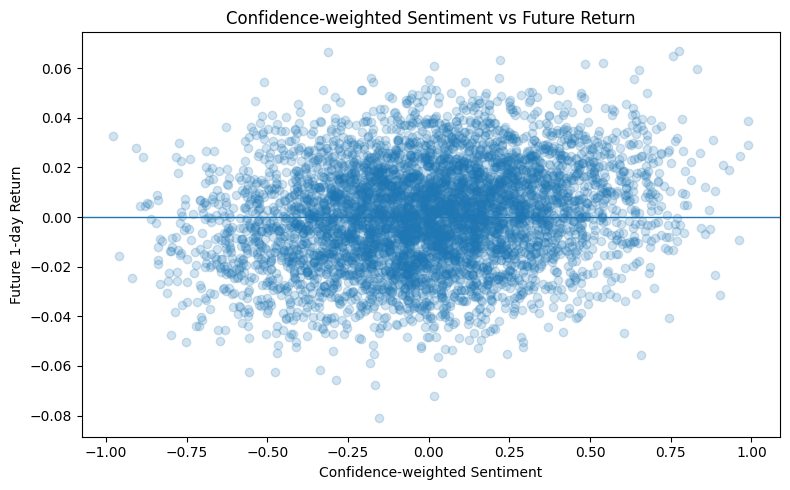

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(
    df["confidence_weighted_sentiment"],
    df["future_return_1d"],
    alpha=0.2
)

plt.xlabel("Confidence-weighted Sentiment")
plt.ylabel("Future 1-day Return")

plt.title(
    "Confidence-weighted Sentiment vs Future Return"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

### Feature 1 Interpretation

The relationship is noisy, but the correlation check shows whether higher confidence-weighted sentiment is associated with higher future returns.

A small positive relationship would be consistent with the project's hypothesis that high-confidence positive sentiment may contain useful predictive information. Because stock returns are noisy, this feature should later be evaluated out of sample rather than judged only from this in-sample relationship.

### Rationale for Feature 2
Explain why this feature may help a model. Reference your EDA.

## Feature 2 — 3-day Sentiment Change

### Rationale

Stage 08 EDA highlighted the importance of examining time-series structure rather than looking only at the current level of a variable.

For sentiment research, a sudden improvement or deterioration in news sentiment may contain different information from a sentiment score that has remained stable.

Therefore, I create `sentiment_change_3d`, which measures the difference between today's sentiment and the sentiment three trading observations earlier for the same stock.

Using lagged sentiment ensures that the feature only uses current and historical information and avoids look-ahead bias.

In [12]:
df = df.sort_values(
    ["stock_id", "date"]
).reset_index(drop=True)

In [13]:
df["sentiment_lag_3d"] = (
    df
    .groupby("stock_id")["news_sentiment"]
    .shift(3)
)

df["sentiment_change_3d"] = (
    df["news_sentiment"]
    - df["sentiment_lag_3d"]
)

df[
    [
        "date",
        "stock_id",
        "news_sentiment",
        "sentiment_lag_3d",
        "sentiment_change_3d"
    ]
].head(10)

,date,stock_id,news_sentiment,sentiment_lag_3d,sentiment_change_3d
0,2023-01-02,600000.SH,0.475841,NaN,NaN
1,2023-01-03,600000.SH,0.398316,NaN,NaN
2,2023-01-04,600000.SH,-0.079003,NaN,NaN
3,2023-01-05,600000.SH,-0.429555,0.475841,-0.905396
4,2023-01-06,600000.SH,-0.129837,0.398316,-0.528153
5,2023-01-09,600000.SH,-0.402077,-0.079003,-0.323074
6,2023-01-10,600000.SH,0.002268,-0.429555,0.431823
7,2023-01-11,600000.SH,-0.328040,-0.129837,-0.198203
8,2023-01-12,600000.SH,-0.697538,-0.402077,-0.295461
9,2023-01-13,600000.SH,0.404435,0.002268,0.402167


In [14]:
feature2_corr = (
    df[
        [
            "sentiment_change_3d",
            "future_return_1d"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between 3-day sentiment change "
    "and future return:",
    round(feature2_corr, 4)
)

Correlation between 3-day sentiment change and future return: 0.1374


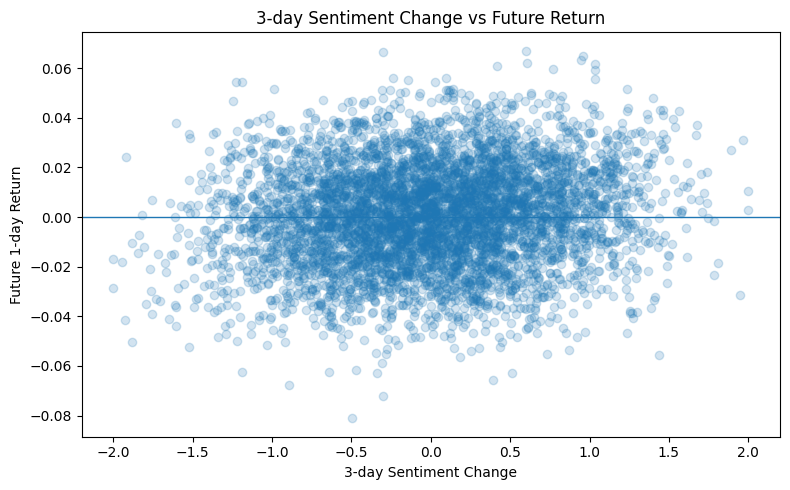

In [15]:
feature2_plot = df.dropna(
    subset=[
        "sentiment_change_3d",
        "future_return_1d"
    ]
)

plt.figure(figsize=(8, 5))

plt.scatter(
    feature2_plot["sentiment_change_3d"],
    feature2_plot["future_return_1d"],
    alpha=0.2
)

plt.xlabel("3-day Sentiment Change")
plt.ylabel("Future 1-day Return")

plt.title(
    "3-day Sentiment Change vs Future Return"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

### Feature 2 Interpretation

The correlation and scatter plot test whether recent changes in sentiment contain information about future stock returns.

If the correlation is positive, improving sentiment may be associated with slightly stronger future returns. If the relationship is weak, it suggests that sentiment change alone may have limited predictive value and should be evaluated together with other factors.

### Rationale for Feature 3
Explain why this feature may help a model. Reference your EDA. If this is your
categorical encoding, say why you chose that encoding over the other two.

## Feature 3 — Market Regime One-Hot Encoding

### Rationale

Stage 08 EDA showed that categorical variables should be examined separately and converted into numerical representations before they are used in most machine-learning models.

The project also considers market-regime dependence as an important risk because sentiment signals may behave differently during bullish, bearish, and volatile markets.

I use one-hot encoding rather than label encoding because `Bull`, `Bear`, and `Volatile` are categories without a natural numerical order.

One-hot encoding allows each market regime to be represented independently without incorrectly assuming that one regime is numerically larger than another.




In [16]:
regime_dummies = pd.get_dummies(
    df["market_regime"],
    prefix="regime",
    dtype=int
)

regime_dummies.head()

,regime_Bear,regime_Bull,regime_Volatile
0,1,0,0
1,1,0,0
2,0,0,1
3,0,0,1
4,0,1,0


In [17]:
df = pd.concat(
    [
        df,
        regime_dummies
    ],
    axis=1
)

df[
    [
        "market_regime",
        "regime_Bear",
        "regime_Bull",
        "regime_Volatile"
    ]
].head(10)

,market_regime,regime_Bear,regime_Bull,regime_Volatile
0,Bear,1,0,0
1,Bear,1,0,0
2,Volatile,0,0,1
3,Volatile,0,0,1
4,Bull,0,1,0
5,Volatile,0,0,1
6,Volatile,0,0,1
7,Volatile,0,0,1
8,Volatile,0,0,1
9,Bull,0,1,0


In [18]:
regime_return = (
    df
    .groupby("market_regime")[
        "future_return_1d"
    ]
    .mean()
)

regime_return

market_regime
Bear       -0.002892
Bull        0.003238
Volatile    0.000544
Name: future_return_1d, dtype: float64

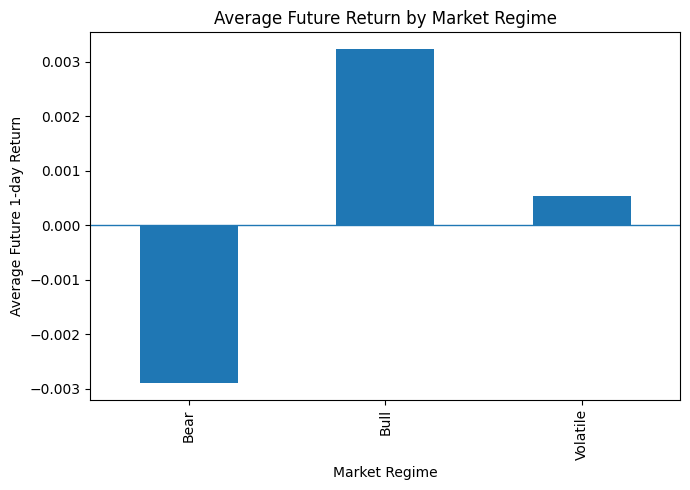

In [19]:
plt.figure(figsize=(7, 5))

regime_return.plot(
    kind="bar"
)

plt.xlabel("Market Regime")
plt.ylabel("Average Future 1-day Return")

plt.title(
    "Average Future Return by Market Regime"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

### Feature 3 Interpretation

Average future returns differ across market regimes in the synthetic dataset.

This suggests that market conditions may contain useful information and should be retained as control features when evaluating the sentiment factor. The one-hot encoded regime variables also make it possible for later models to account for different market environments.

# Feature Engineering Summary

Three engineered feature groups were created.

### 1. `confidence_weighted_sentiment`

Combines sentiment direction with sentiment-model confidence. It is designed to reduce the influence of low-confidence sentiment observations.

### 2. `sentiment_change_3d`

Measures short-term changes in sentiment relative to three trading observations earlier. It captures sentiment momentum while using only historical information.

### 3. Market regime one-hot encoding

Converts the categorical `market_regime` variable into numerical dummy variables for Bull, Bear, and Volatile periods.

Each engineered feature was motivated by Stage 08 EDA findings and evaluated against `future_return_1d` using either a correlation check, visualization, or group comparison.

Because the dataset is synthetic, the observed relationships demonstrate the feature-engineering workflow and should not be interpreted as empirical evidence about real A-share returns.

In [20]:
from src.features import add_features
test_df = add_features(
    df_raw
)

test_df.head()

,date,stock_id,industry,market_regime,news_sentiment,sentiment_confidence,news_count,daily_return,market_return,turnover,volatility_5d,future_return_1d,confidence_weighted_sentiment,sentiment_lag_3d,sentiment_change_3d,regime_Bear,regime_Bull,regime_Volatile
0,2023-01-02,600000.SH,Healthcare,Bear,0.475841,0.675136,3,0.010159,-0.008140,0.073726,NaN,-0.019522,0.321257,NaN,NaN,1,0,0
1,2023-01-03,600000.SH,Healthcare,Bear,0.398316,0.990000,4,-0.010385,-0.025375,0.064371,NaN,0.018445,0.394333,NaN,NaN,1,0,0
2,2023-01-04,600000.SH,Healthcare,Volatile,-0.079003,0.758187,5,-0.041522,-0.007254,0.141083,NaN,0.003555,-0.059899,NaN,NaN,0,0,1
3,2023-01-05,600000.SH,Healthcare,Volatile,-0.429555,0.596518,2,0.013023,0.007473,0.100477,NaN,-0.031977,-0.256238,0.475841,-0.905396,0,0,1
4,2023-01-06,600000.SH,Healthcare,Bull,-0.129837,0.564840,2,0.051886,0.031014,0.130651,0.030626,-0.006368,-0.073337,0.398316,-0.528153,0,1,0


In [21]:
test_df[
    [
        "confidence_weighted_sentiment",
        "sentiment_change_3d",
        "regime_Bear",
        "regime_Bull",
        "regime_Volatile"
    ]
].head(10)

,confidence_weighted_sentiment,sentiment_change_3d,regime_Bear,regime_Bull,regime_Volatile
0,0.321257,NaN,1,0,0
1,0.394333,NaN,1,0,0
2,-0.059899,NaN,0,0,1
3,-0.256238,-0.905396,0,0,1
4,-0.073337,-0.528153,0,1,0
5,-0.296945,-0.323074,0,0,1
6,0.001063,0.431823,0,0,1
7,-0.204043,-0.198203,0,0,1
8,-0.404215,-0.295461,0,0,1
9,0.196723,0.402167,0,1,0
